# Insider transaction analysis

Pull a year of insider transactions for one issuer, load them into pandas,
and look at who is selling and when.

Needs `pandas` and `matplotlib` on top of py3spread, and a free API key in
`THREESPREAD_API_KEY` ([signup](https://3spread.com/auth/signup)).

In [1]:
import datetime as dt

import pandas as pd

from py3spread import Client

TICKER = "AAPL"
client = Client()

end = dt.date.today()
start = end - dt.timedelta(days=365)

# edgar indexes each form under both issuer and owner cik, so the stream
# returns every transaction twice; dedupe on (accession, record_index)
rows = {}
for txn in client.insiders.iter_transactions(
    issuer_ticker=TICKER,
    transaction_start=str(start),
    transaction_end=str(end),
    transaction_kind="nonderiv",
):
    accession = txn["filing_id"].split("_", 1)[1]
    rows[(accession, txn["record_index"])] = txn

df = pd.DataFrame(rows.values())
df["transaction_date"] = pd.to_datetime(df["transaction_date"])
for col in ["transaction_shares", "transaction_price_per_share", "transaction_total_value"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
print(f"{len(df)} transactions")
df[["transaction_date", "filer_name", "transaction_code",
    "transaction_shares", "transaction_total_value"]].head()

69 transactions


,transaction_date,filer_name,transaction_code,transaction_shares,transaction_total_value
0,2026-06-16,Borders Ben,S,116.0,34236.24
1,2026-06-15,Newstead Jennifer,M,30104.0,NaN
2,2026-06-15,Newstead Jennifer,F,16238.0,4813267.96
3,2026-06-15,Borders Ben,M,240.0,NaN
4,2026-06-15,Borders Ben,F,124.0,36756.08


Values arrive as strings at full precision; `decimal.Decimal` is the right
type for accounting math, but floats are fine for exploratory analysis
like this.

## Who sold the most

In [2]:
sells = df[df["transaction_acquired_disposed_code"] == "D"]
(sells.groupby("filer_name")["transaction_total_value"]
    .agg(total="sum", trades="count")
    .sort_values("total", ascending=False)
    .head(10)
    .style.format({"total": "${:,.0f}"}))

,total,trades
filer_name,,
COOK TIMOTHY D,"$104,533,005",12
LEVINSON ARTHUR D,"$92,076,022",5
O'BRIEN DEIRDRE,"$47,892,620",7
Adams Katherine L.,"$23,667,419",6
Khan Sabih,"$21,133,500",2
Newstead Jennifer,"$12,949,171",2
Parekh Kevan,"$4,747,816",7
KONDO CHRIS,"$1,920,016",3
Borders Ben,"$678,108",4


## Monthly sell volume

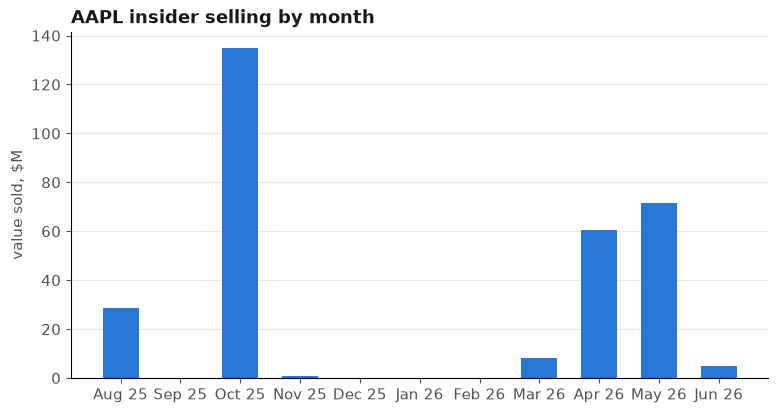

In [3]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (9, 4.5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#e8e7e2",
    "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "font.size": 11,
    "text.color": "#1a1a19",
    "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
})
BLUE = "#2a78d6"


monthly = (sells.set_index("transaction_date")["transaction_total_value"]
    .resample("MS").sum() / 1e6)

fig, ax = plt.subplots()
ax.bar(monthly.index.strftime("%b %y"), monthly.values, color=BLUE, width=0.6)
ax.set_title(f"{TICKER} insider selling by month", loc="left", fontweight="bold")
ax.set_ylabel("value sold, $M")
ax.grid(axis="x", visible=False)
plt.show()

## Sentiment at a glance

`buy_sell_ratio` aggregates it server-side over a trailing window.

In [4]:
client.insiders.buy_sell_ratio(ticker=TICKER, window_days=90)

{'cik': None,
 'ticker': 'AAPL',
 'sic': None,
 'since': '2026-04-03',
 'until': '2026-07-02',
 'buys_dollars': '0',
 'sells_dollars': '156759894.2800000000000000',
 'buys_count': 0,
 'sells_count': 18,
 'buy_sell_ratio': 0}